##Week 5 Factor Analysis Follow Along Coding in Python
DSCI-590: Applied Data Science, Owen Randolph, 9/23/2024

In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42564 sha256=dee885efbb5e2f3eae468ea32ec01f827e75b9c35843fed0c6214abffb3f27d4
  Stored in directory: /root/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer


In [ ]:
import pandas as pd
from sklearn import datasets
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import FactorAnalysis, PCA
import matplotlib.pyplot as plt
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity


In [ ]:
iris = datasets.load_iris()

###Normalize Data

In [ ]:
iris_X = StandardScaler().fit_transform(iris.data)
pd.DataFrame(iris_X).head()

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [ ]:
# Get feature names from column
feature_names = iris["feature_names"]

###Covariance Matrix

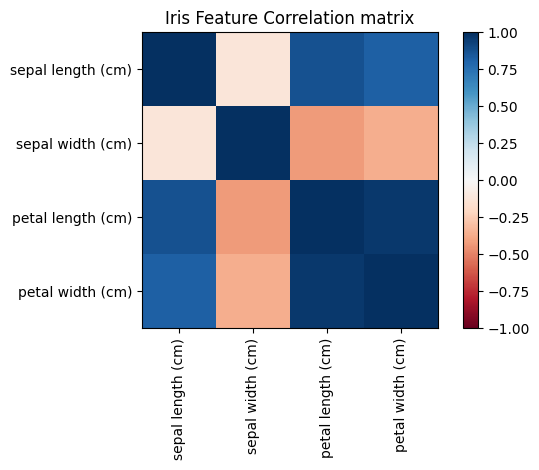

In [ ]:
plt.figure()
ax = plt.axes()
im = ax.imshow(np.corrcoef(iris_X.T), cmap= "RdBu", vmin=-1, vmax=1)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(list(feature_names), rotation=90)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(list(feature_names))
plt.colorbar(im)
ax.set_title("Iris Feature Correlation matrix")
plt.tight_layout()
plt.show()

###Adequacy Test

In [ ]:
# Bartlett's Test
chi_square_value, p_value=calculate_bartlett_sphericity(iris_X)
chi_square_value, p_value

(706.9592430234726, 1.9226796044171964e-149)

In [ ]:
# Kaiser_Meyer_Olkin Test(KMO)
kmo_all, kmo_model=calculate_kmo(iris_X)
kmo_model

0.540076675009722

##### We will procced with the factor analysis (> 0.5)

###Number of Factors

In [ ]:
fa = FactorAnalyzer()
fa.fit(iris_X, 4)
# Check Eigenvalues
ev, v = fa.get_eigenvalues()

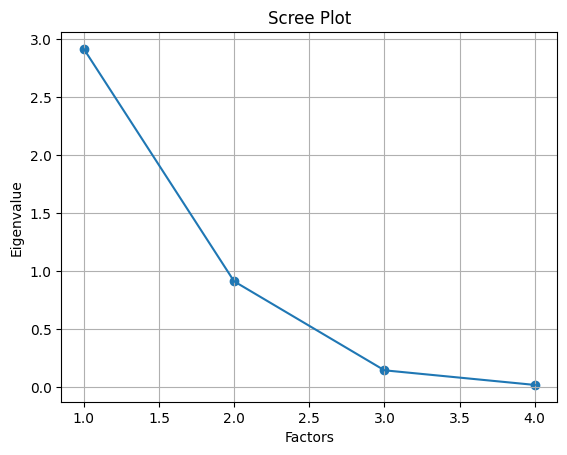

In [ ]:
# Create scree plot using matplotlib
plt.scatter(range(1, iris_X.shape[1]+1),ev)
plt.plot(range(1, iris_X.shape[1]+1),ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show();

#####Choose the value at the elbow or look at values around 1.

###Perform Factor Analysis

In [ ]:
fa = FactorAnalyzer(rotation="varimax", n_factors=2)
fa.fit(iris_X, 2, )

FactorAnalyzer(n_factors=2, rotation='varimax', rotation_kwargs={})

In [ ]:
fa.get_eigenvalues()

(array([2.91849782, 0.91403047, 0.14675688, 0.02071484]),
 array([ 2.84243329,  0.88505993,  0.00853874, -0.01435222]))

In [ ]:
print(pd.DataFrame(fa.loadings_, index=feature_names))

                          0         1
sepal length (cm)  0.901205  0.017890
sepal width (cm)  -0.150413  0.986195
petal length (cm)  0.964153 -0.284619
petal width (cm)   0.921401 -0.233245


#####The loading score will range from -1 to 1. Values close to -1 or 1 indicate that the factor has an influence on these variables.  Values close to 0 indicates that the factor has a lower influencer on the variable.

###Variance
#####1. Sum of squared loadings (variance)
#####2. Proportional variance
#####3. Cumulative variance

In [ ]:
print(pd.DataFrame(fa.get_factor_variance(),
                   index = ['sum','proportional', 'cumulative']))

                     0         1
sum           2.613367  1.108312
proportional  0.653342  0.277078
cumulative    0.653342  0.930420


#####Look at acculmulative variance: 2 factors together explain 93% of the variance.